In [3]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit_ibm_runtime.fake_provider import FakeManilaV2
from qiskit import transpile
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import numpy as np

In [80]:
qc = QuantumCircuit(4, 2)

qc.x([0, 1])

#qc.barrier()

qc.cx([0, 1], [2, 2])
qc.ccx(0, 1, 3)

#qc.barrier()

qc.measure([2, 3], [0 , 1])
#qc.measure_all()

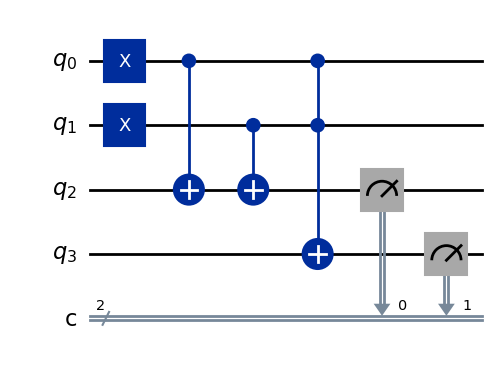

In [81]:
qc.draw('mpl')

In [82]:
backend = FakeManilaV2()

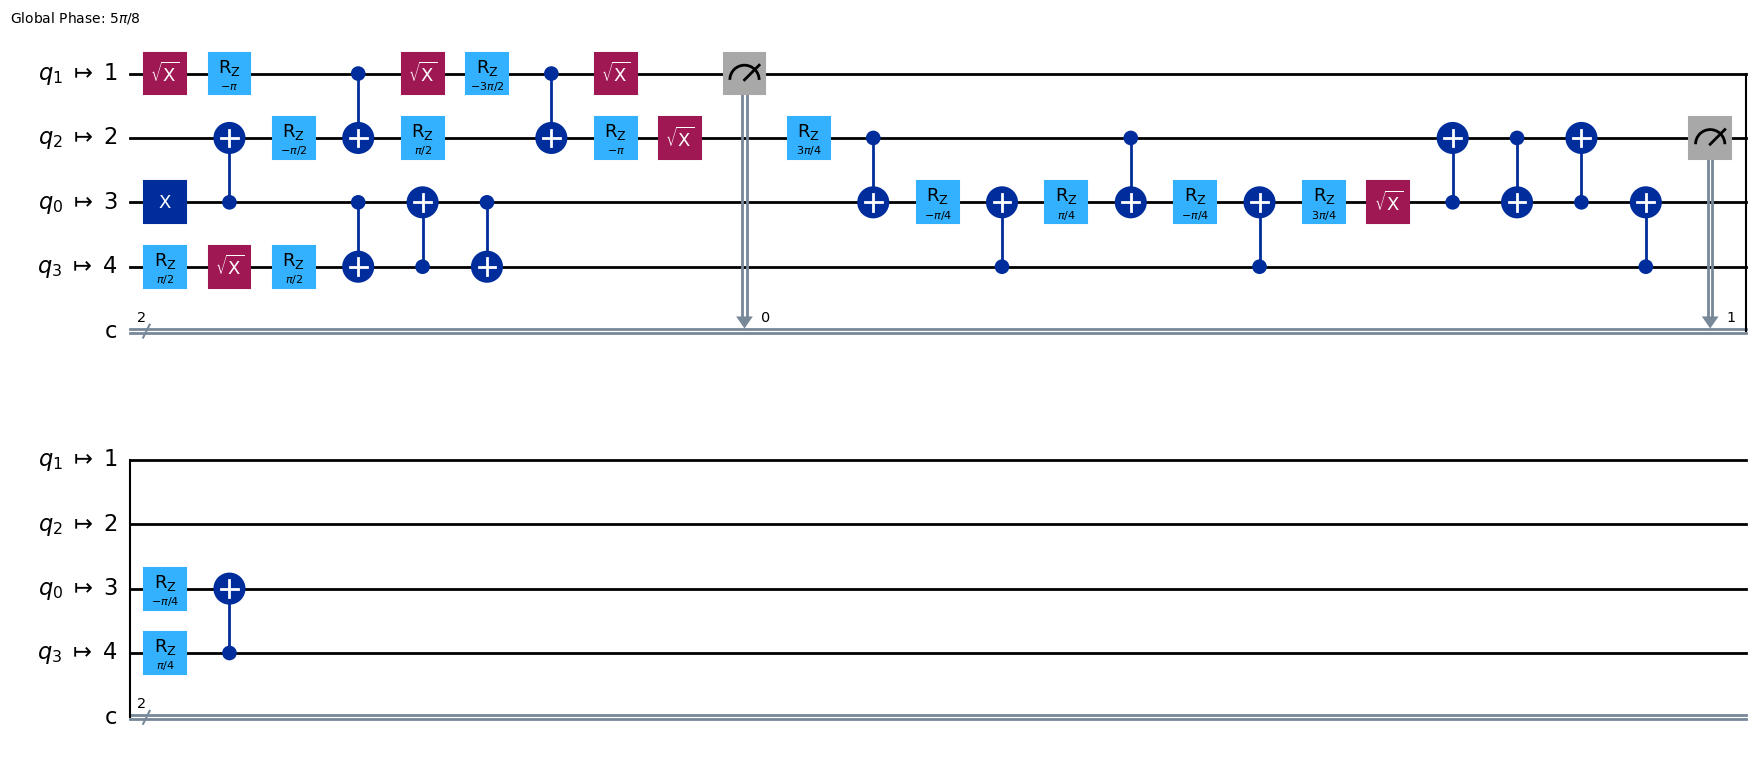

In [83]:
# Transpile the ideal circuit to a circuit that can be
# directly executed by the backend
transpiled_circuit = transpile(qc, backend)
transpiled_circuit.draw('mpl', style="iqp")

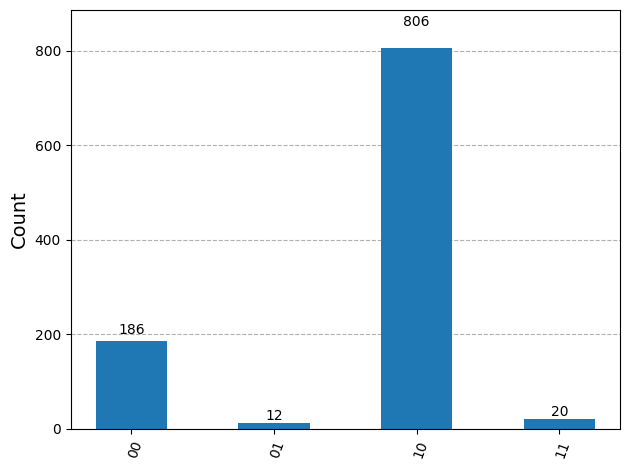

In [84]:
# Run the transpiled circuit using the simulated fake backend
sampler = SamplerV2(backend)
job = sampler.run([transpiled_circuit])
pub_result = job.result()[0]
counts = pub_result.data.c.get_counts()
plot_histogram(counts)